# Etapa 1: Importación de las bibliotecas

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

# Etapa 2: Importación de la base de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/NYC_taxi_trip_duration.zip'
df_train = pd.read_csv(path)

In [ ]:
print(f"Trip_duration_train.shape: {df_train.shape}")

Trip_duration_train.shape: (1458644, 11)


In [ ]:
df_train.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


# Etapa 3: Vision General de los Datos

In [ ]:
df_train.keys()

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [ ]:
df_train.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


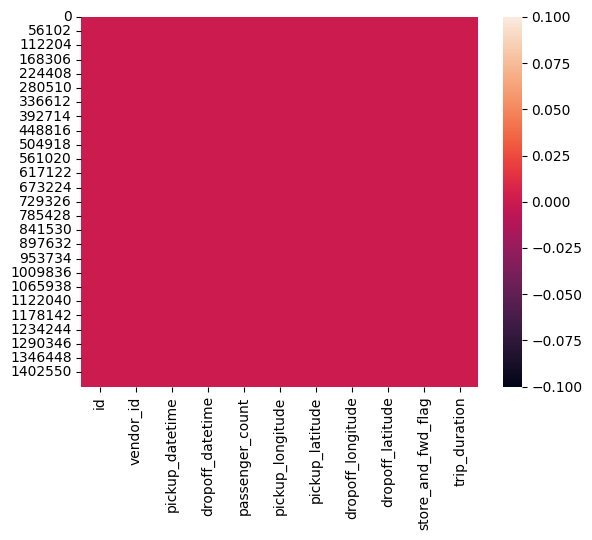

In [ ]:
sns.heatmap(df_train.isnull());

In [ ]:
info = pd.DataFrame({
    "tipo"    : df_train.dtypes,
    "nulos"   : df_train.isnull().sum(),
    "únicos"  : df_train.nunique(),
})
print(info.to_string())

                       tipo  nulos   únicos
id                   object      0  1458644
vendor_id             int64      0        2
pickup_datetime      object      0  1380222
dropoff_datetime     object      0  1380377
passenger_count       int64      0       10
pickup_longitude    float64      0    23047
pickup_latitude     float64      0    45245
dropoff_longitude   float64      0    33821
dropoff_latitude    float64      0    62519
store_and_fwd_flag   object      0        2
trip_duration         int64      0     7417


In [ ]:
df_train['id'].duplicated().sum()

np.int64(0)

In [ ]:
df_train.drop(columns=['id'], inplace=True) #eliminacion de id
df_train['pickup_datetime'] = pd.to_datetime(df_train['pickup_datetime']) #convirtiendo a tipo fecha
df_train.dtypes

,0
vendor_id,int64
pickup_datetime,datetime64[ns]
dropoff_datetime,object
passenger_count,int64
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
store_and_fwd_flag,object
trip_duration,int64


# Etapa 4: Limpieza de datos

Se eliminaran filas que son fisicamente imposibles o son un error. Usamos umbrales basados en conocimiento del dominio (por ejemplo un viaje no puede durar menos de 10 segundos o mas de 3 horas dentrode NYC).

In [ ]:
# Problemas encontrados
df_train[df_train['pickup_latitude'] < 40.50].head(2) #no esta dentro de NY
df_train[df_train['trip_duration'] == 1].head(2) #no seria realista
df_train[df_train['passenger_count'] == 0].head(2) #o que no haya pasajeros en el taxi
df_train.shape

(1458644, 10)

In [ ]:
def limpiar_datos(X: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia los datos crudos de viajes en taxi antes de la ingeniería de características.

    Elimina filas no realistas basadas en:
      1. Límites de duración del viaje
      2. Bounding box geográfico para NYC
      3. Conteo de pasajeros válido

    Esto asegura que el modelo se entrene solo con viajes reales,
    reduciendo ruido y mejorando la estabilidad.
    """

    MIN_DURACION   =    10 #minimo en segundos de viajes
    MAX_DURACION   = 10_800 #maximo en segundos

    # Bounding box aproximado para Nueva York
    LAT_MIN, LAT_MAX =  40.50,  40.93
    LON_MIN, LON_MAX = -74.25, -73.65

    # Mantener viajes en rango de duración valido
    mascara_duracion = X['trip_duration'].between(MIN_DURACION, MAX_DURACION)

    # Mantener recogidas dentro del bounding box de NYC
    mascara_recogida = (
        X['pickup_latitude'].between(LAT_MIN, LAT_MAX) &
        X['pickup_longitude'].between(LON_MIN, LON_MAX)
    )

    # Mantener entregas dentro del bounding box de NYC
    mascara_entrega = (
        X['dropoff_latitude'].between(LAT_MIN, LAT_MAX) &
        X['dropoff_longitude'].between(LON_MIN, LON_MAX)
    )

    # Eliminar viajes con cero pasajeros negativos
    mascara_pasajeros = X['passenger_count'] > 0

    # Aplicar todos
    X = X[mascara_duracion & mascara_recogida & mascara_entrega & mascara_pasajeros].copy()

    # Reiniciar índice después de eliminar filas
    X.reset_index(drop=True, inplace=True)

    return X

filas_antes = len(df_train)
print(f"Filas antes de limpiar: {filas_antes:,}")
df_train = limpiar_datos(df_train)
print(f"Filas después de limpiar: {len(df_train):,}")
print(f"Eliminadas: {filas_antes - len(df_train):,} filas")

Filas antes de limpiar: 1,458,644
Filas después de limpiar: 1,453,522
Eliminadas: 5,122 filas


# Etapa 5: Ingenieria de caracteristicas

In [ ]:
RADIO_TIERRA_KM = 6_371.0 #este es el radio medio de la tierra

def calcular_distancia(lon1, lat1, lon2, lat2):
    """
    Formula Haversine — distancia de gran circulo entre dos puntos en la tierra.
    Devuelve distancia en kilometros.
    """
    #Convertir grados decimales a radianes
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    d_phi = np.radians(lat2 - lat1)
    d_lambda = np.radians(lon2 - lon1)

    #Formula principal
    a = (np.sin(d_phi / 2) ** 2 +
         np.cos(phi1) * np.cos(phi2) * np.sin(d_lambda / 2) ** 2)
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return RADIO_TIERRA_KM * c #kilometros

def calcular_direccion(lon1, lat1, lon2, lat2):
    """
    Azimut forward (direccion) de punto 1 a punto 2.
    Devuelve el angulo en grados (−180 a +180).
    Util como proxy para dirección de corredor de tráfico.
    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    d_lon = lon2 - lon1
    y = np.sin(d_lon) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(d_lon)
    return np.degrees(np.arctan2(y, x))

In [ ]:
#Aplicando caracteristicas espaciales
df_train['distance_km'] = calcular_distancia(
    df_train['pickup_longitude'], df_train['pickup_latitude'],
    df_train['dropoff_longitude'], df_train['dropoff_latitude']
)

df_train['bearing'] = calcular_direccion(
    df_train['pickup_longitude'],  df_train['pickup_latitude'],
    df_train['dropoff_longitude'], df_train['dropoff_latitude']
)

df_train["manhattan_distance"] = (
    abs(df_train["pickup_latitude"] - df_train["dropoff_latitude"]) +
    abs(df_train["pickup_longitude"] - df_train["dropoff_longitude"])
)

In [ ]:
from sklearn.cluster import MiniBatchKMeans

coords = np.vstack((
    df_train[['pickup_latitude','pickup_longitude']].values,
    df_train[['dropoff_latitude','dropoff_longitude']].values
))

kmeans = MiniBatchKMeans(n_clusters=100, batch_size=10000).fit(coords)

df_train['pickup_cluster'] = kmeans.predict(
    df_train[['pickup_latitude','pickup_longitude']]
)

df_train['dropoff_cluster'] = kmeans.predict(
    df_train[['dropoff_latitude','dropoff_longitude']]
)

In [ ]:
#caracteristicas temporales
dt = df_train['pickup_datetime'].dt

df_train['hour'] = dt.hour
df_train['dayofweek'] = dt.dayofweek # 0 = Lunes y 6 = Domingo
df_train['month'] = dt.month
df_train['nombre_dia_semana'] = dt.day_name()
df_train['es_fin_semana'] = (dt.dayofweek >= 5).astype(int)

In [ ]:
#Codificacion ciclica ya que hora 23 y 0 esta cerca pero el modelo los ve como lejanos
df_train['hour_sin'] = np.sin(2 * np.pi * df_train['hour']/24)
df_train['hour_cos'] = np.cos(2 * np.pi * df_train['hour']/24)
df_train['day_sin'] = np.sin(2 * np.pi * df_train['dayofweek']/7)
df_train['day_cos'] = np.cos(2 * np.pi * df_train['dayofweek']/7)

In [ ]:
#Velocidad, NO usar en modelado (var. objetivo) solo para el EDA
df_train['speed_kmh'] = df_train['distance_km'] / (df_train['trip_duration'] / 3600)
df_train = df_train[df_train["speed_kmh"] < 120]
df_train = df_train[df_train["speed_kmh"] > 1]

In [ ]:
# Eliminar columna de datetime ahora que extrajimos todo
df_train.drop(columns=['pickup_datetime'], inplace=True)

print(f"Forma final: {df_train.shape}")
df_train.head()

Forma final: (1443380, 24)


,vendor_id,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,...,hour,dayofweek,month,nombre_dia_semana,es_fin_semana,hour_sin,hour_cos,day_sin,day_cos,speed_kmh
0,2,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,1.498521,...,17,0,3,Monday,0,-0.965926,-0.258819,0.000000,1.000000,11.856428
1,1,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,1.805507,...,0,6,6,Sunday,1,0.000000,1.000000,-0.781831,0.623490,9.803659
2,2,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,6.385098,...,11,1,1,Tuesday,0,0.258819,-0.965926,0.781831,0.623490,10.822201
3,2,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,1.485498,...,19,2,4,Wednesday,0,-0.965926,0.258819,0.974928,-0.222521,12.465721
4,2,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,1.188588,...,13,5,3,Saturday,1,-0.258819,-0.965926,-0.974928,-0.222521,9.836594


# Etapa 6: Analisis Exploratorio de Datos (EDA)

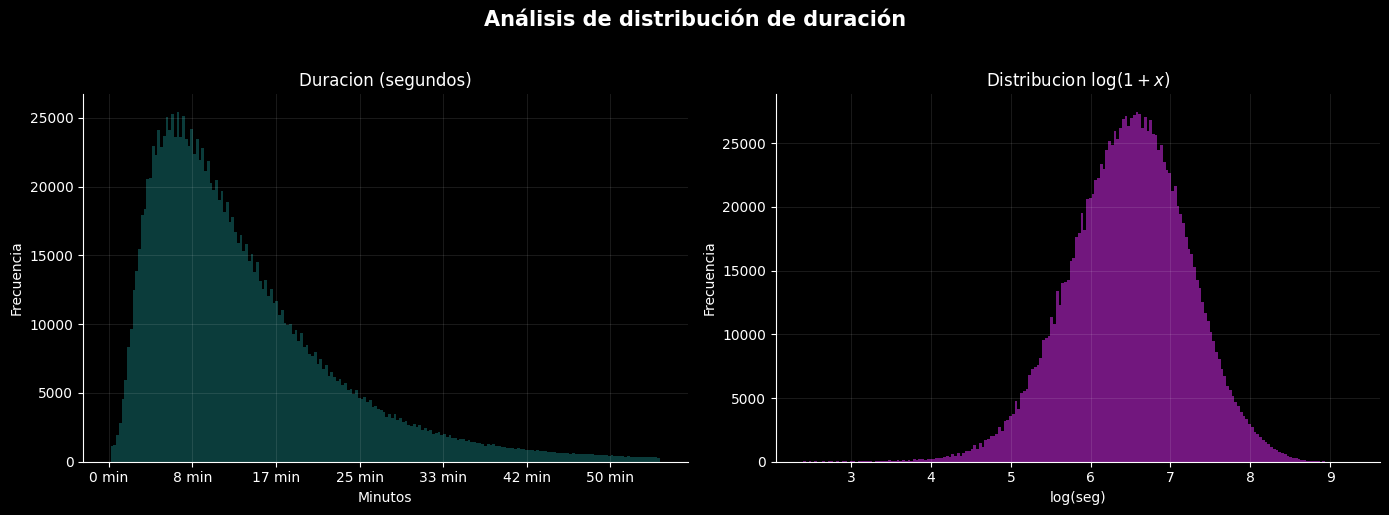

In [ ]:
plt.style.use('dark_background')
c_raw, c_log = '#0F4C4A', '#8F1E9E'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cap = df_train['trip_duration'].quantile(0.99)
d_hist = df_train.loc[df_train['trip_duration'] <= cap, 'trip_duration']
d_log = np.log1p(df_train['trip_duration'])

axes[0].hist(d_hist, bins=200, color=c_raw, alpha=0.8)
axes[0].set(title="Duracion (segundos)", xlabel="Minutos", ylabel="Frecuencia")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/60:.0f} min"))

axes[1].hist(d_log, bins=200, color=c_log, alpha=0.8)
axes[1].set(title=r"Distribucion $\log(1 + x)$", xlabel="log(seg)", ylabel="Frecuencia")

for ax in axes:
    ax.grid(alpha=0.1)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("Análisis de distribución de duración", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

La distribucion esta sesgada a la derecha, es decir, que la mayoria de los viajes son cortos, pero hay una cola larga de viajes largos. Por eso usaremos transformación logarítmica en el modelado (como se ve en la segunda imagen, ese es el objetivo)

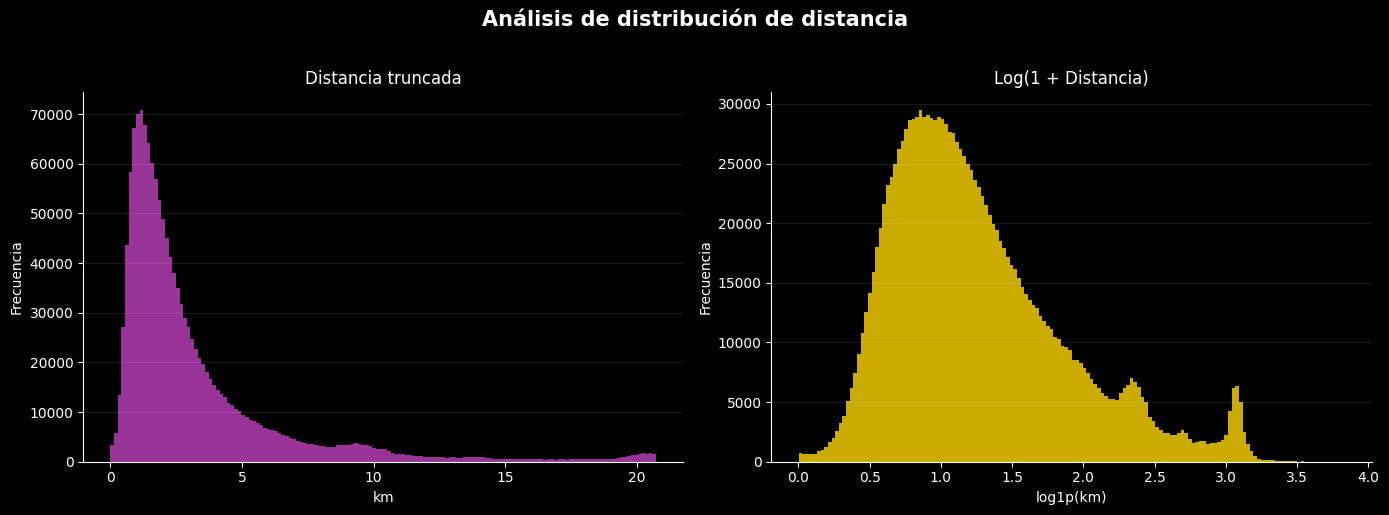

Mediana: 2.09 km | Promedio: 3.26 km


In [ ]:
plt.style.use('dark_background')
c1, c2 = '#BF40BF', '#FFD700'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cap = df_train['distance_km'].quantile(0.99)
d_hist = df_train.loc[df_train['distance_km'] <= cap, 'distance_km']
d_log = np.log1p(df_train['distance_km'])

axes[0].hist(d_hist, bins=150, color=c1, alpha=0.8)
axes[0].set(title="Distancia truncada", xlabel="km", ylabel="Frecuencia")

axes[1].hist(d_log, bins=150, color=c2, alpha=0.8)
axes[1].set(title="Log(1 + Distancia)", xlabel="log1p(km)", ylabel="Frecuencia")

for ax in axes: ax.grid(axis='y', alpha=0.1); ax.spines[['top', 'right']].set_visible(False)
plt.suptitle("Análisis de distribución de distancia", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print(f"Mediana: {d_hist.median():.2f} km | Promedio: {d_hist.mean():.2f} km")

La distancia también tiene un sesgo fuerte a la derecha. La mayoría de viajes en taxi en Nueva York son menores a 10 km, eso es logico, ya que es una ciudad densa o muy llena.

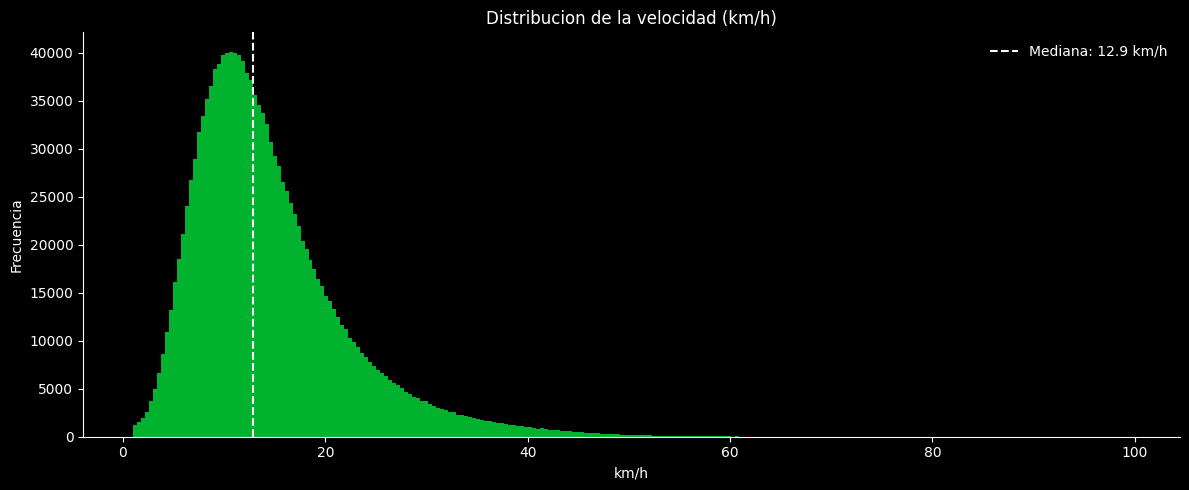

Viajes con velocidad < 1 km/h: 0   ← probablemente GPS malo
Viajes con velocidad > 80 km/h: 66  ← sospechosamente rapido


In [ ]:
plt.style.use('dark_background')
v_eda = df_train['speed_kmh'][(df_train['speed_kmh'] > 0) & (df_train['speed_kmh'] <= 100)]
median = v_eda.median()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(v_eda, bins=250, color='#00FF41', alpha=0.7)
ax.axvline(median, color='white', ls='--', lw=1.5, label=f"Mediana: {median:.1f} km/h")
ax.set(title="Distribucion de la velocidad (km/h)", xlabel="km/h", ylabel="Frecuencia")
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout(); plt.show()
print(f"Viajes con velocidad < 1 km/h: {(df_train['speed_kmh'] < 1).sum():,}   ← probablemente GPS malo")
print(f"Viajes con velocidad > 80 km/h: {(df_train['speed_kmh'] > 80).sum():,}  ← sospechosamente rapido")

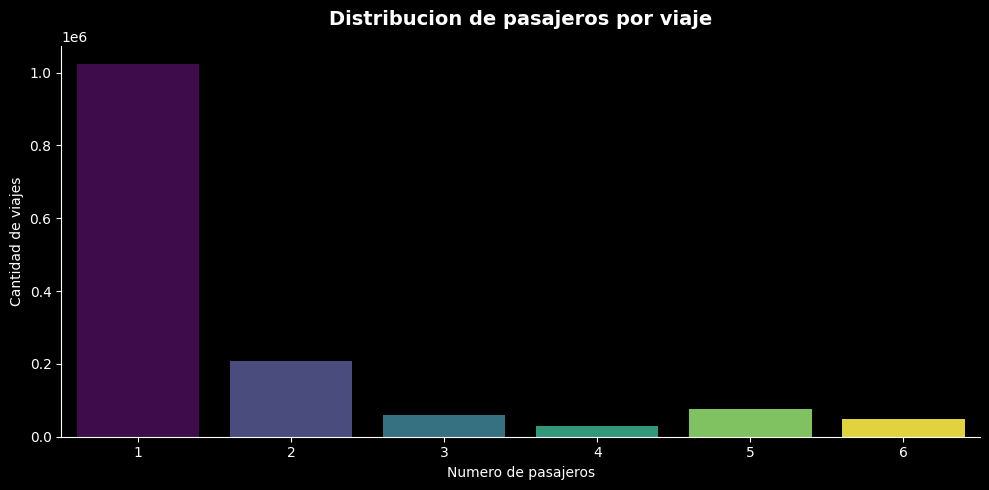

In [ ]:
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))
ax = sns.countplot(x="passenger_count", data=df_train, palette="viridis", hue="passenger_count", legend=False)
plt.title("Distribucion de pasajeros por viaje", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Numero de pasajeros")
plt.ylabel("Cantidad de viajes")
sns.despine()

plt.tight_layout()
plt.show()

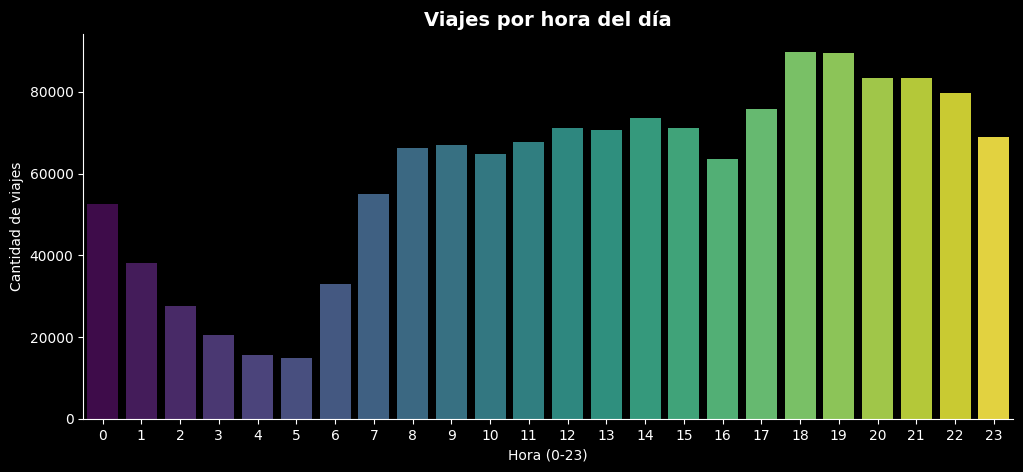

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(x="hour", data=df_train, palette="viridis", hue="hour", legend=False)

plt.title("Viajes por hora del día", fontsize=14, fontweight='bold')
plt.xlabel("Hora (0-23)")
plt.ylabel("Cantidad de viajes")
sns.despine()

plt.show()

Mayor actividad durante horas laborales y menor actividad en la madrugada.Esto refleja patrones de movilidad urbana.

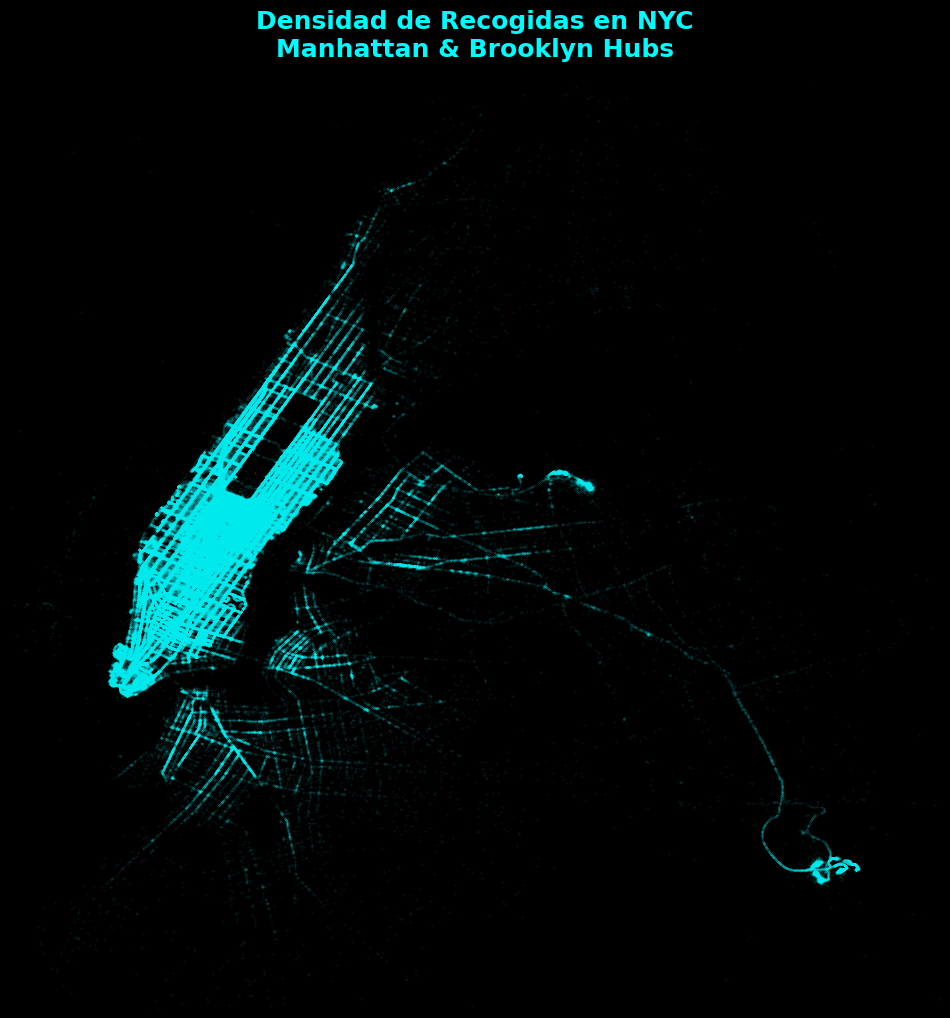

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')
plt.figure(figsize=(12, 12), facecolor='black')
plt.scatter(df_train["pickup_longitude"], df_train["pickup_latitude"],
            s=0.05, color='#00FBFF', alpha=0.2)
plt.xlim(-74.05, -73.75)
plt.ylim(40.6, 40.9)
plt.title("Densidad de Recogidas en NYC\nManhattan & Brooklyn Hubs",
          fontsize=18, pad=20, color='#00FBFF', fontweight='bold')
plt.axis('off')

plt.show()

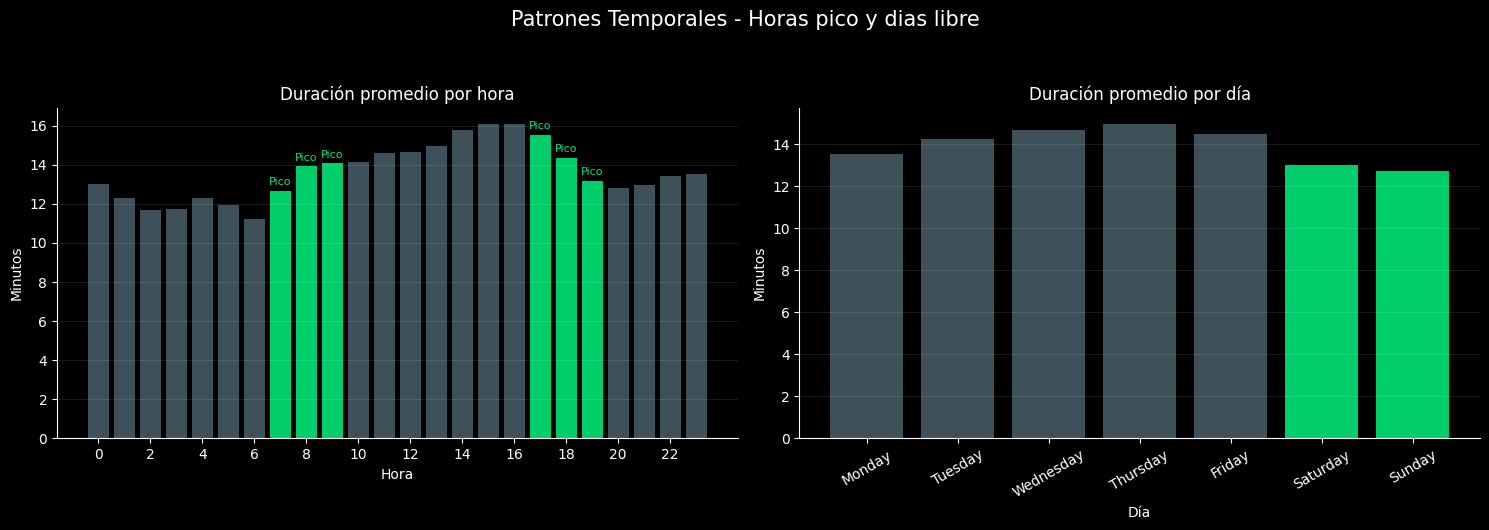

In [ ]:
plt.style.use('dark_background')
base_col, highlight_col = '#455A64', '#00E676'

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
h_avg = df_train.groupby('hour')['trip_duration'].mean() / 60
picos = [7, 8, 9, 17, 18, 19]
clrs_h = [highlight_col if h in picos else base_col for h in h_avg.index]

axes[0].bar(h_avg.index, h_avg.values, color=clrs_h, alpha=0.9)
axes[0].set(title="Duración promedio por hora", xlabel="Hora", xticks=range(0, 24, 2))
[axes[0].text(h, h_avg[h] + 0.3, 'Pico', ha='center', fontsize=8, color=highlight_col) for h in picos]

dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
d_avg = (df_train.groupby('nombre_dia_semana')['trip_duration'].mean() / 60).reindex(dias)
clrs_d = [highlight_col if d in ['Saturday','Sunday'] else base_col for d in dias]

axes[1].bar(d_avg.index, d_avg.values, color=clrs_d, alpha=0.9)
axes[1].set(title="Duración promedio por día", xlabel="Día")
axes[1].tick_params(axis='x', rotation=30)

for ax in axes:
    ax.set_ylabel("Minutos")
    ax.grid(axis='y', alpha=0.1)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("Patrones Temporales - Horas pico y dias libre", fontsize=15, y=1.05)
plt.tight_layout(); plt.show()

Las horas pico y fines de semana son las señales temporales más fuertes para la duración.

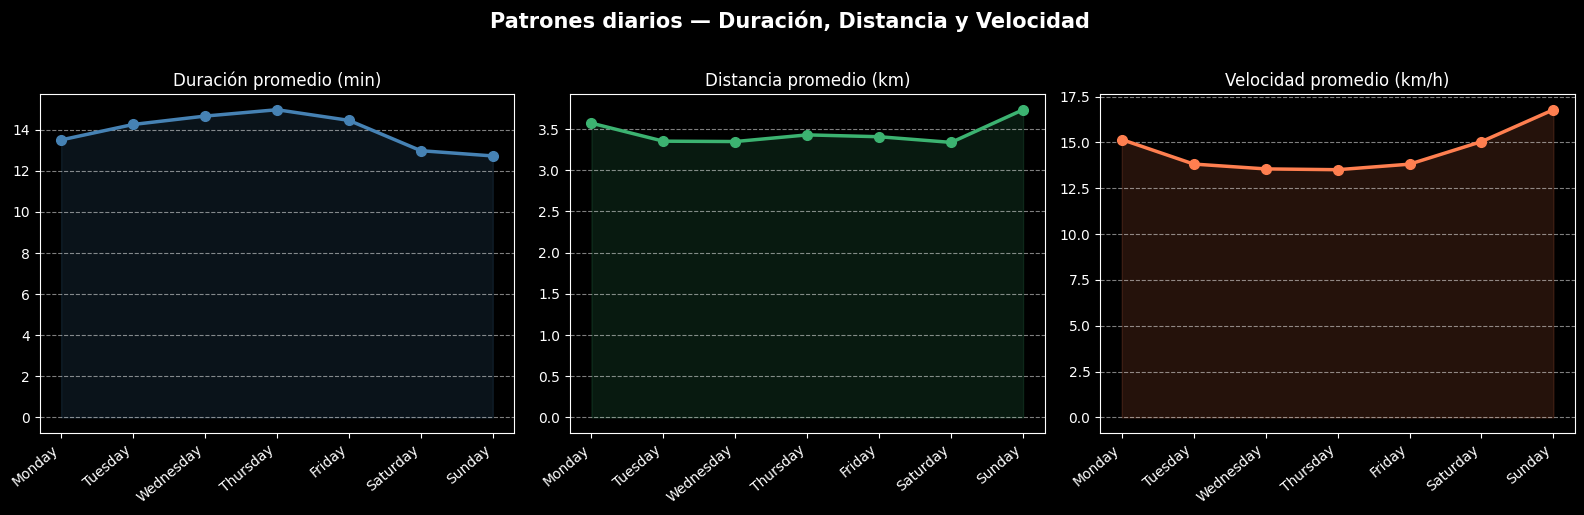

In [ ]:
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
agg = df_train.groupby('nombre_dia_semana').agg(
    prom_duracion = ('trip_duration', 'mean'),
    prom_distancia = ('distance_km',   'mean'),
    prom_velocidad    = ('speed_kmh',     'mean'),
).reindex(orden_dias)
agg['prom_duracion'] /= 60   # Convertir a minutos

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas  = ['prom_duracion', 'prom_distancia', 'prom_velocidad']
titulos   = ['Duración promedio (min)', 'Distancia promedio (km)', 'Velocidad promedio (km/h)']
colores   = ['steelblue', 'mediumseagreen', 'coral']

for ax, metrica, titulo, color in zip(axes, metricas, titulos, colores):
    ax.plot(agg.index, agg[metrica], marker='o', linewidth=2.5,
            markersize=7, color=color)
    ax.fill_between(range(7), agg[metrica].values, alpha=0.15, color=color)
    ax.set_title(titulo)
    ax.set_xticks(range(7))
    ax.set_xticklabels(orden_dias, rotation=40, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Patrones diarios — Duración, Distancia y Velocidad", fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Ver estas tres metricas juntas muestra si viajes más largos en ciertos días son por distancia o congestion (velocidad lenta).

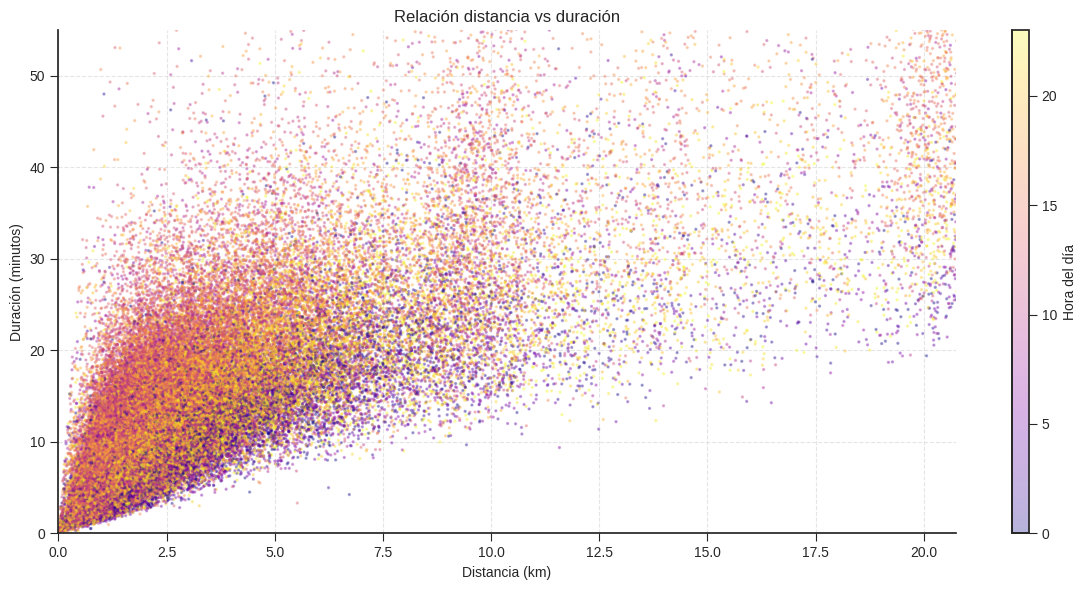

In [ ]:
plt.style.use('seaborn-v0_8-ticks')
fig, ax = plt.subplots(figsize=(12, 6))

cap_d, cap_t = df_train['distance_km'].quantile(0.99), df_train['trip_duration'].quantile(0.99)
m = df_train.sample(n=min(100_000, len(df_train)), random_state=42)
sc = ax.scatter(m.distance_km, m.trip_duration / 60, c=m.hour,
                cmap='plasma', alpha=0.3, s=2)
plt.colorbar(sc, label='Hora del día', aspect=30)
ax.set(xlim=(0, cap_d), ylim=(0, cap_t / 60),
       xlabel="Distancia (km)", ylabel="Duración (minutos)",
       title="Relación distancia vs duración")

ax.grid(True, linestyle='--', alpha=0.5)
sns.despine()

plt.tight_layout(); plt.show()

La señal más clara, es decir, que los viajes más largos toman más tiempo al taxista, pero con dispersión por tráfico.

In [ ]:
df_train.keys()

Index(['vendor_id', 'dropoff_datetime', 'passenger_count', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'store_and_fwd_flag', 'trip_duration', 'distance_km', 'bearing',
       'manhattan_distance', 'pickup_cluster', 'dropoff_cluster', 'hour',
       'dayofweek', 'month', 'nombre_dia_semana', 'es_fin_semana', 'hour_sin',
       'hour_cos', 'day_sin', 'day_cos', 'speed_kmh'],
      dtype='object')

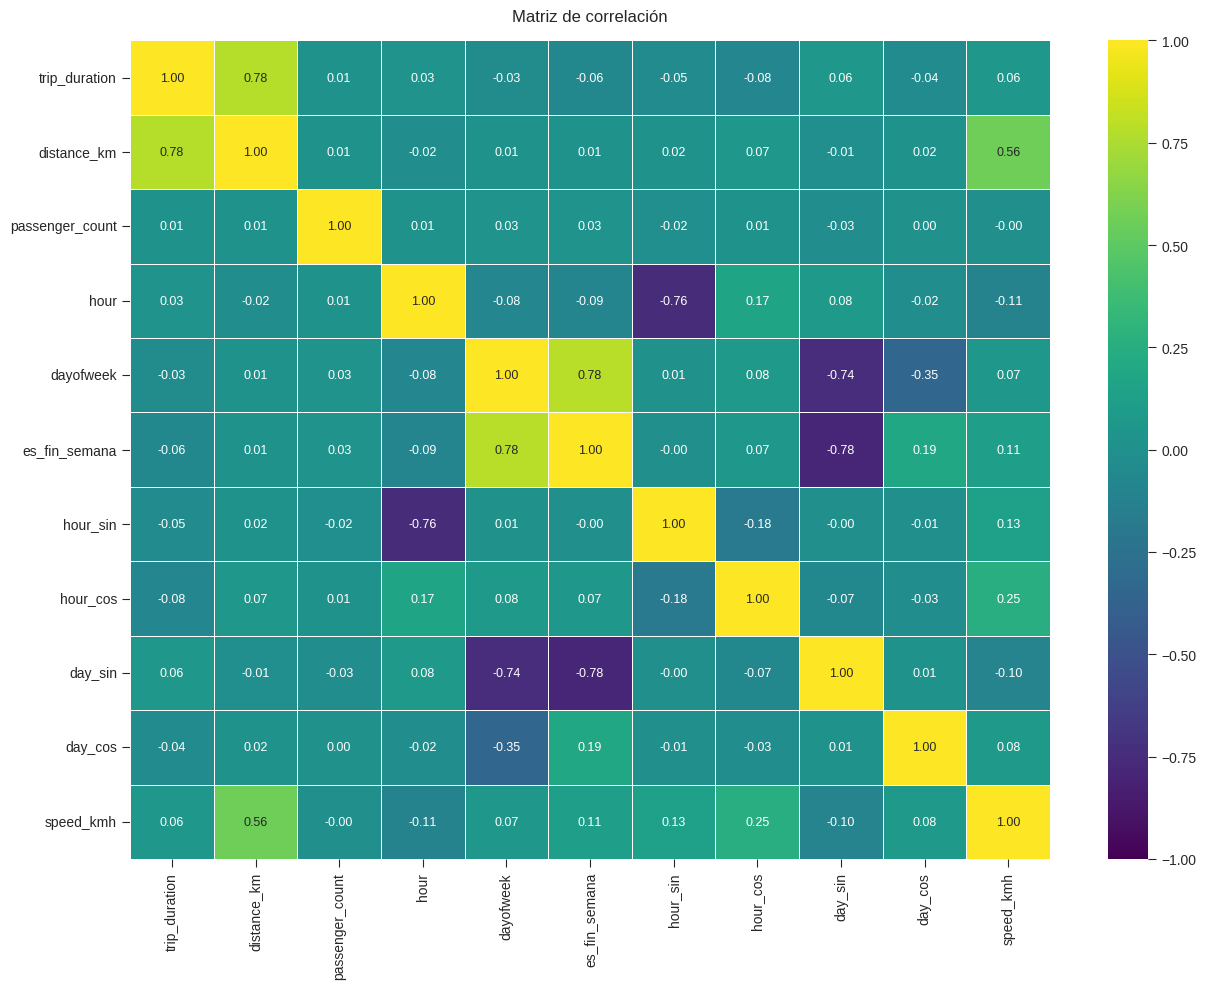

In [ ]:
columnas_corr = [
    'trip_duration', 'distance_km', 'passenger_count',
    'hour', 'dayofweek', 'es_fin_semana',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'speed_kmh',
]

corr = df_train[columnas_corr].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='viridis', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title("Matriz de correlación", pad=14)
plt.tight_layout()
plt.show()

El mapa de calor muestra correlaciones lineales entre características numericas. distance_km tiene la correlación más fuerte con la duración. Por su parte speed_kmh muestra alta correlación porque se deriva de la variable objetivo, en realidad no es una señal real.

# Etapa 7: Tratamiento de las bases de datos

In [ ]:
df_train.drop(columns=["hour", "nombre_dia_semana", "es_fin_semana", "speed_kmh", "pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude", "dropoff_datetime"], inplace=True)

In [ ]:
df_train.shape

(1443380, 15)

In [ ]:
#conversion de trip duration a logaritmo
df_train["log_trip_duration"] = np.log1p(df_train["trip_duration"])

In [ ]:
# Separamos X e y del dataframe 'df'
X = df_train.drop(["trip_duration","log_trip_duration"], axis=1)
y = df_train["log_trip_duration"]

In [ ]:
#conversion de la unica variable con onehot encoding
X = pd.get_dummies(X, columns=["store_and_fwd_flag"], drop_first=True)

In [ ]:
# Dividimo 80% para entrenar, 20% para evaluar
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1154704, 14)
X_test: (288676, 14)


In [ ]:
X.keys()

Index(['vendor_id', 'passenger_count', 'distance_km', 'bearing',
       'manhattan_distance', 'pickup_cluster', 'dropoff_cluster', 'dayofweek',
       'month', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
       'store_and_fwd_flag_Y'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = [
    "passenger_count",
    "distance_km",
    "bearing",
    "manhattan_distance"
]

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

# Etapa 8: Construcción y entrenamiento del modelo

In [ ]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

model = Sequential()

# Capa 1
model.add(Dense(256, activation="relu", kernel_initializer="he_normal", input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.30))

# Capa 2
model.add(Dense(128, activation="relu", kernel_initializer="he_normal"))
model.add(BatchNormalization())
model.add(Dropout(0.30))

# Capa 3
model.add(Dense(64, activation="relu", kernel_initializer="he_normal"))
model.add(BatchNormalization())
model.add(Dropout(0.20))

# Capa 4
model.add(Dense(32, activation="relu"))

# Salida
model.add(Dense(1))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,897 (191.00 KB)

 Trainable params: 48,001 (187.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
#Compilacion del modelo
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

In [ ]:
#armando los callbacks
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=5,
    min_lr=0.00001
)

In [ ]:
#Construccion del modelo
history = model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/150
1805/1805 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 4.4756 - mae: 1.3045 - val_loss: 0.2082 - val_mae: 0.3515 - learning_rate: 0.0010
Epoch 2/150
1805/1805 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.4313 - mae: 0.5191 - val_loss: 0.1854 - val_mae: 0.3301 - learning_rate: 0.0010
Epoch 3/150
1805/1805 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2899 - mae: 0.4215 - val_loss: 0.1745 - val_mae: 0.3193 - learning_rate: 0.0010
Epoch 4/150
1805/1805 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.1970 - mae: 0.3417 - val_loss: 0.1654 - val_mae: 0.3094 - learning_rate: 0.0010
Epoch 5/150
1805/1805 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1802 - mae: 0.3251 - val_loss: 0.1626 - val_mae: 0.3065 - learning_rate: 0.0010
Epoch 6/150
1805/1805 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.1732 - mae: 0.3182 - val_loss: 0.1565 - val_mae: 0.3005 - learning_rate: 0.0010
Epoch 7/150
1805/1805 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1687 - mae: 0.3136 - val_loss: 0.1535 - val_mae: 0.2976 - learni

# Etapa 9: Verificación del modelo

In [ ]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae', 'learning_rate'])

In [ ]:
y_pred_log = model.predict(X_test)

9022/9022 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step


In [ ]:
#transformación inversa de log1p
y_pred = np.expm1(y_pred_log)
y_real = np.expm1(y_test)

In [ ]:
model.evaluate(X_test, y_test)

9022/9022 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - loss: 0.1266 - mae: 0.2682


[0.12640425562858582, 0.268411785364151]

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

MSE = mean_squared_error(y_real, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_real, y_pred)
R2 = r2_score(y_real, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]

Adjusted_R2 = 1 - (1 - R2) * (n - 1) / (n - p - 1)

print("MSE:", MSE)
print("RMSE:", RMSE)
print("MAE:", MAE)
print("R2:", R2)
print("Adjusted R2:", Adjusted_R2)

MSE: 103899.1321283558
RMSE: 322.3338829976703
MAE: 200.95333845441715
R2: 0.755547959410545
Adjusted R2: 0.755536103536117


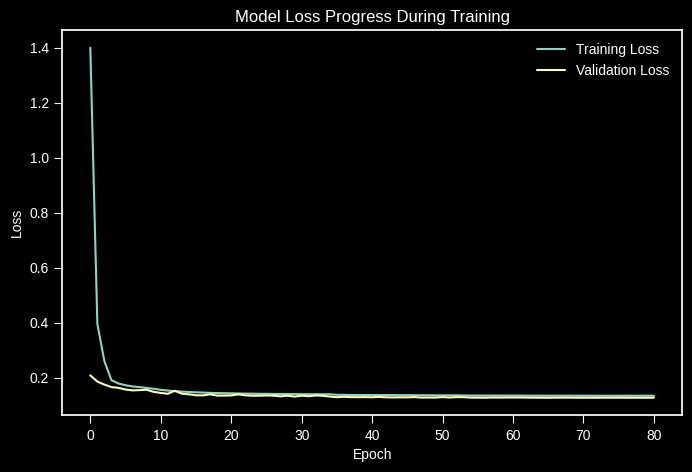

In [ ]:
plt.style.use('dark_background')
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss Progress During Training")
plt.legend()

plt.show();

9022/9022 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


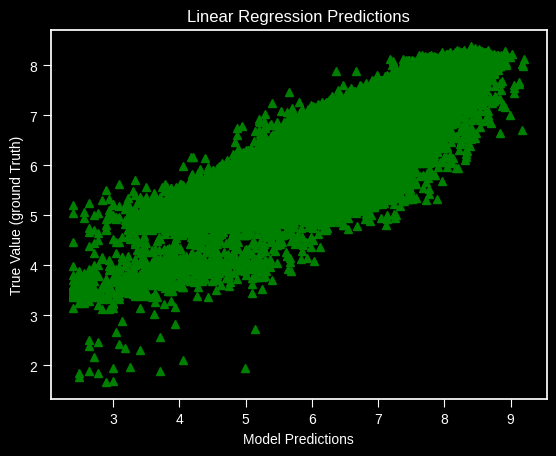

In [ ]:
plt.style.use('dark_background')
y_predict = model.predict(X_test)
plt.plot(y_test, y_predict, "^", color = 'green')
plt.xlabel("Model Predictions")
plt.ylabel("True Value (ground Truth)")
plt.title('Linear Regression Predictions')
plt.show()

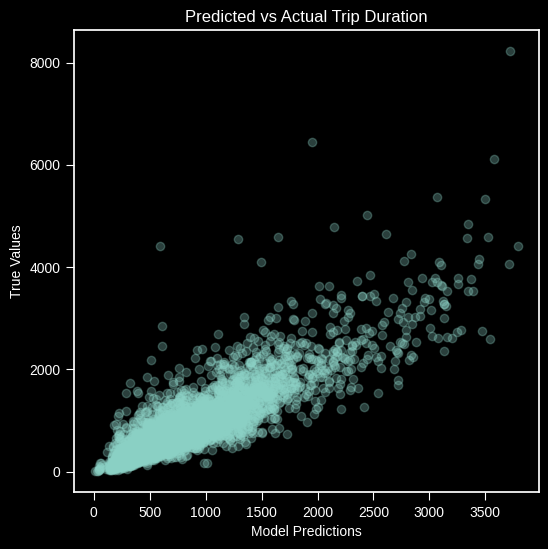

In [ ]:
plt.style.use('dark_background')
plt.figure(figsize=(6,6))
sample = 5000
plt.scatter(
    y_pred[:sample],
    y_real[:sample],
    alpha=0.3
)
plt.xlabel("Model Predictions")
plt.ylabel("True Values")
plt.title("Predicted vs Actual Trip Duration")
plt.show()

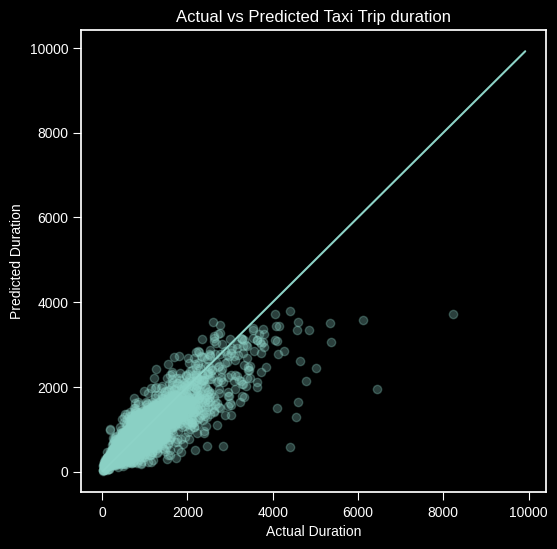

In [ ]:
plt.style.use('dark_background')
plt.figure(figsize=(6,6))
plt.scatter(
    y_real[:5000],
    y_pred[:5000],
    alpha=0.3
)
plt.plot(
    [y_real.min(), y_real.max()],
    [y_real.min(), y_real.max()],
)
plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.title("Actual vs Predicted Taxi Trip duration")
plt.show()